# **_笔记前言_**


1. 初始化参数：

- 1.1：使用 0 来初始化参数。
- 1.2：使用随机数来初始化参数。
- 1.3：使用抑梯度异常初始化参数（参见视频中的梯度消失和梯度爆炸）。

2. 正则化模型：

- 2.1：使用二范数对二分类模型正则化，尝试避免过拟合。
- 2.2：使用随机删除节点的方法精简模型，同样是为了尝试避免过拟合。

3. 梯度校验 ：对模型使用梯度校验，检测它是否在梯度下降的过程中出现误差过大的情况。


# **_深度神经网络的初始化_**


① 训练神经网络需要指定权重的初始值，而一个好的初始化方法将有助于网络学习。

② 如果你完成了本系列的上一课程，则可能已经按照我们的说明完成了权重初始化。

③ 但是，如何为新的神经网络选择初始化？在本 notebook 中，你能学习看到不同的初始化导致的不同结果。

④ 好的初始化可以：

1. 加快梯度下降、模型收敛
2. 减小梯度下降收敛过程中训练（和泛化）出现误差的几率


# 0. 要解决的问题


① 我们希望分类器将蓝点和红点分开。


# 1. 导入库


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
from andrew_dl.l2.l2w1 import init_utils
from andrew_dl.l2.l2w1 import reg_utils
from andrew_dl.l2.l2w1.testCases import *

# 如果使用的是Jupyter Notebook，加上 %matplotlib inline
%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0) # 设置 plot 的默认大小
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [13]:
import importlib
importlib.reload(init_utils)

<module 'andrew_dl.l2.l2w1.init_utils' from 'd:\\ai\\cv\\I-AccumulateMore-CV\\andrew_dl\\l2\\l2w1\\init_utils.py'>

# 2. 读取并绘制数据


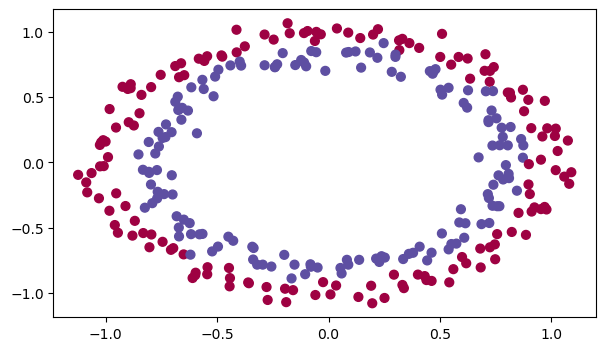

In [14]:
# 加载图像数据集:蓝色/红色的圆点
train_X, train_Y, test_X, test_Y = init_utils.load_dataset(is_plot=True)

# 3. 初始化模型


## 3.1 初始化模型简介


① 我们将要建立一个分类器把蓝点和红点分开，在之前我们已经实现过一个 3 层的神经网络，我们将对它进行初始化。

② 我们将会尝试下面三种初始化方法:

1. 初始化为 0：在输入参数中全部初始化为 0，参数名为 initialization = “zeros”，核心代码：parameters['W' + str(l)] = np.zeros((layers_dims[l], layers_dims[l - 1]))

2. 初始化为随机数：把输入参数设置为随机值，权重初始化为大的随机值。参数名为 initialization = “random”，核心代码：parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l - 1]) \* 10

3. 抑梯度异常初始化：参见梯度消失和梯度爆炸的那一个视频，参数名为 initialization = “he”，这是根据 He 等人（2015）的论文将权重初始化为按比例缩放的随机值。核心代码：parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l - 1]) \* np.sqrt(2 / layers_dims[l - 1])


## 3.2 初始化模型样式


① 首先我们来看看我们的模型是怎样的。

② 模型可以简单地看一下，我们接下来将尝试以上三种初始化。


In [15]:
def model(X, Y, learning_rate=0.01, num_iterations=15000, print_cost=True, initialization="he", is_polt=True):
    """
    实现一个三层的神经网络：LINEAR ->RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID
    参数：
        X - 输入的数据，维度为(2, 要训练/测试的数量)
        Y - 标签，【0 | 1】，维度为(1，对应的是输入的数据的标签)
        learning_rate - 学习速率
        num_iterations - 迭代的次数
        print_cost - 是否打印成本值，每迭代1000次打印一次
        initialization - 字符串类型，初始化的类型【"zeros" | "random" | "he"】
        is_polt - 是否绘制梯度下降的曲线图
    返回
        parameters - 学习后的参数
    """
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 10, 5, 1]
    # 选择初始化参数的类型
    if initialization == "zeros":
        parameters = initialize_parameters_zeros(layers_dims)
    elif initialization == "random":
        parameters = initialize_parameters_random(layers_dims)
    elif initialization == "he":
        parameters = initialize_parameters_he(layers_dims)
    else:
        print("错误的初始化参数！程序退出")
        exit
    # 开始学习
    for i in range(0, num_iterations):
        # 前向传播
        a3, cache = init_utils.forward_propagation(X, parameters)
        # 计算成本
        cost = init_utils.compute_loss(a3, Y)
        # 反向传播
        grads = init_utils.backward_propagation(X, Y, cache)
        # 更新参数
        parameters = init_utils.update_parameters(
            parameters, grads, learning_rate)
        # 记录成本
        if i % 1000 == 0:
            costs.append(cost)
            # 打印成本
            if print_cost:
                print("第" + str(i) + "次迭代，成本值为：" + str(cost))
    # 学习完毕，绘制成本曲线
    if is_polt:
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (per hundreds)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()
    # 返回学习完毕后的参数
    return parameters

### 3.2.1 初始化为零


① 在神经网络中有两种类型的参数要初始化：

1. 权重矩阵$(W^{[1]}, W^{[2]}, W^{[3]}, ..., W^{[L-1]}, W^{[L]})$
2. 偏差向量$(b^{[1]}, b^{[2]}, b^{[3]}, ..., b^{[L-1]}, b^{[L]})$

② 我们实现以下函数以将所有参数初始化为零。


In [16]:
def initialize_parameters_zeros(layers_dims):
    """
    将模型的参数全部设置为0
    参数：
        layers_dims - 列表，模型的层数和对应每一层的节点的数量
    返回
        parameters - 包含了所有W和b的字典
            W1 - 权重矩阵，维度为（layers_dims[1], layers_dims[0]）
            b1 - 偏置向量，维度为（layers_dims[1],1）
            ···
            WL - 权重矩阵，维度为（layers_dims[L], layers_dims[L -1]）
            bL - 偏置向量，维度为（layers_dims[L],1）
    """
    parameters = {}
    L = len(layers_dims)  # 网络层数
    for l in range(1, L):
        parameters['W' + str(l)] = np.zeros((layers_dims[l], layers_dims[l-1]))
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))
        # 使用断言确保我的数据格式是正确的
        assert (parameters["W" + str(l)].shape ==
                (layers_dims[l], layers_dims[l-1]))
        assert (parameters["b" + str(l)].shape == (layers_dims[l], 1))
    return parameters

In [17]:
print("======我们来测试一下======")
parameters = initialize_parameters_zeros([3, 2, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

======我们来测试一下======
W1 = [[0. 0. 0.]
 [0. 0. 0.]]
b1 = [[0.]
 [0.]]
W2 = [[0. 0.]]
b2 = [[0.]]


① 我们可以看到 W 和 b 全部被初始化为 0 了，那么我们使用这些参数来训练模型，结果会怎样呢？

② 运行以下代码，使用零初始化并迭代 14,000 次训练模型。


第0次迭代，成本值为：0.6931471805599453
第1000次迭代，成本值为：0.6931471805599453
第2000次迭代，成本值为：0.6931471805599453
第3000次迭代，成本值为：0.6931471805599453
第4000次迭代，成本值为：0.6931471805599453
第5000次迭代，成本值为：0.6931471805599453
第6000次迭代，成本值为：0.6931471805599453
第7000次迭代，成本值为：0.6931471805599453
第8000次迭代，成本值为：0.6931471805599453
第9000次迭代，成本值为：0.6931471805599453
第10000次迭代，成本值为：0.6931471805599455
第11000次迭代，成本值为：0.6931471805599453
第12000次迭代，成本值为：0.6931471805599453
第13000次迭代，成本值为：0.6931471805599453
第14000次迭代，成本值为：0.6931471805599453


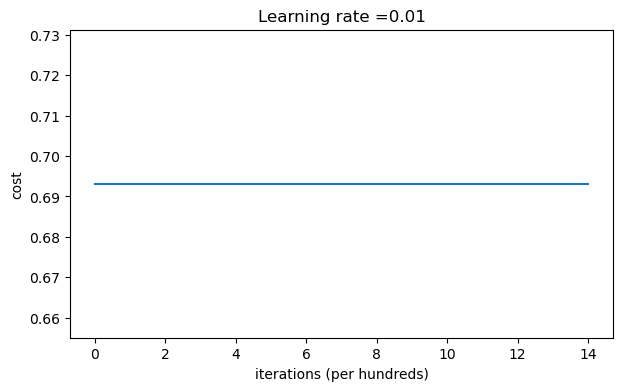

In [18]:
parameters = model(train_X, train_Y, initialization="zeros", is_polt=True)

③ 从上图中我们可以看到学习率一直没有变化，也就是说这个模型根本没有学习。我们来看看预测的结果怎么样：


In [19]:
print("训练集:")
predictions_train = init_utils.predict(train_X, train_Y, parameters)
print("测试集:")
predictions_test = init_utils.predict(test_X, test_Y, parameters)

训练集:
Accuracy: 0.5
测试集:
Accuracy: 0.5


④ 性能确实很差，损失也没有真正降低，该算法的性能甚至不如随机猜测。

⑤ 为什么呢？让我们看一下预测的详细信息和决策边界：


predictions_train = [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0]]
predictions_test = [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


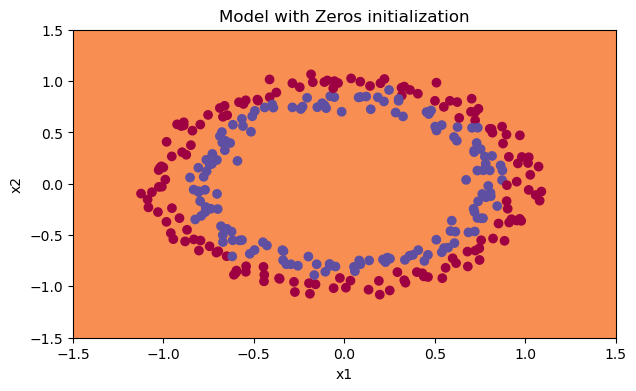

In [20]:
print("predictions_train = " + str(predictions_train))
print("predictions_test = " + str(predictions_test))

plt.title("Model with Zeros initialization")
# plt.gca() 获取当前的坐标轴对象，然后使用 set_xlim 和 set_ylim 方法设置坐标轴的范围
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
init_utils.plot_decision_boundary(
    lambda x: init_utils.predict_dec(parameters, x.T), train_X, train_Y)

⑥ 该模型预测的每个示例都为 0。

⑦ 通常，将所有权重初始化为零会导致网络无法打破对称性。 这意味着每一层中的每个神经元都将学习相同的东西，并且你不妨训练每一层的神经网络，且该网络的性能不如线性分类器，例如逻辑回归。


你应该记住：

1. 权重$W^{[l]}$应该随机初始化以打破对称性。
2. 将偏差$b^{[l]}$初始化为零是可以的。只要随机初始化了$W^{[l]}$，对称性仍然会破坏。


### 3.2.2 随机初始化


① 为了打破对称性，让我们随机设置权重。 在随机初始化之后，每个神经元可以继续学习其输入的不同特征。 在本练习中，你将看到如果将权重随机初始化为非常大的值会发生什么。

② 练习：实现以下函数，将权重初始化为较大的随机值（按*10 缩放），并将偏差设为 0。 将 np.random.randn(..,..) * 10 用于权重，将 np.zeros((.., ..))用于偏差。我们使用固定的 np.random.seed(..)，以确保你的“随机”权重与我们的权重匹配。因此，如果运行几次代码后参数初始值始终相同，也请不要疑惑。


In [21]:
def initialize_parameters_random(layers_dims):
    """
    参数：
        layers_dims - 列表，模型的层数和对应每一层的节点的数量
    返回
        parameters - 包含了所有W和b的字典
            W1 - 权重矩阵，维度为（layers_dims[1], layers_dims[0]）
            b1 - 偏置向量，维度为（layers_dims[1],1）
            ···
            WL - 权重矩阵，维度为（layers_dims[L], layers_dims[L -1]）
            b1 - 偏置向量，维度为（layers_dims[L],1）
    """
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims)  # 表示层数的整数
    for l in range(1, L):
        # 使用 10 倍缩放
        parameters['W' + str(l)] = np.random.randn(layers_dims[l],
                                                   layers_dims[l-1])*10
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))
        # 使用断言确保我的数据格式是正确的
        assert (parameters["W" + str(l)].shape ==
                (layers_dims[l], layers_dims[l-1]))
        assert (parameters["b" + str(l)].shape == (layers_dims[l], 1))
    return parameters

In [22]:
print("======我们来测试一下======")
parameters = initialize_parameters_random([3, 2, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

======我们来测试一下======
W1 = [[ 17.88628473   4.36509851   0.96497468]
 [-18.63492703  -2.77388203  -3.54758979]]
b1 = [[0.]
 [0.]]
W2 = [[-0.82741481 -6.27000677]]
b2 = [[0.]]


③ 运行以下代码使用随机初始化迭代 14,000 次以训练模型。

④ 看起来这些参数都是比较大的，我们来看看实际运行会怎么样：


第0次迭代，成本值为：inf
第1000次迭代，成本值为：0.624419586943653


d:\ai\cv\I-AccumulateMore-CV\andrew_dl\l2\l2w1\init_utils.py:52: RuntimeWarning: divide by zero encountered in log
  np.multiply(-np.log(1 - a3), 1 - Y)
d:\ai\cv\I-AccumulateMore-CV\andrew_dl\l2\l2w1\init_utils.py:52: RuntimeWarning: invalid value encountered in multiply
  np.multiply(-np.log(1 - a3), 1 - Y)


第2000次迭代，成本值为：0.5979291007840762
第3000次迭代，成本值为：0.5636674546886186
第4000次迭代，成本值为：0.5501051275741543
第5000次迭代，成本值为：0.5443580020321741
第6000次迭代，成本值为：0.5373711196497005
第7000次迭代，成本值为：0.4705299779520151
第8000次迭代，成本值为：0.39768640961802737
第9000次迭代，成本值为：0.39344833380849853
第10000次迭代，成本值为：0.3920188732906518
第11000次迭代，成本值为：0.38912604502566145
第12000次迭代，成本值为：0.3861328340008755
第13000次迭代，成本值为：0.3849743300969796
第14000次迭代，成本值为：0.3827657293145835


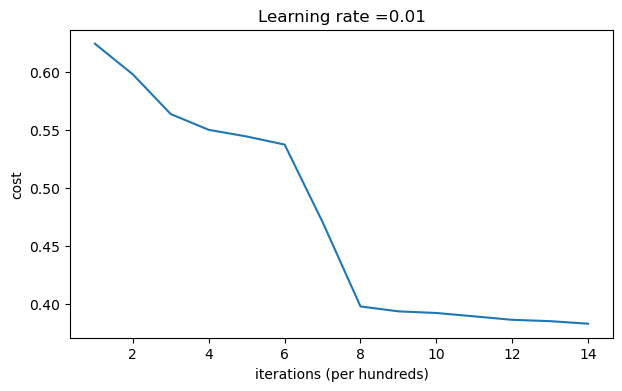

训练集：
Accuracy: 0.83
测试集：
Accuracy: 0.86
[[1 0 1 1 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1
  1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0
  0 0 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0 1 1 0 1 1 0
  1 0 1 1 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0
  0 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1 1
  1 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1
  0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 1 1
  1 1 0 1 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1
  1 1 1 1 0 0 0 1 1 1 1 0]]
[[1 1 1 1 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 1 1 0 0 0 0 1
  0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0
  1 1 1 1 1 0 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0]]


In [23]:
parameters = model(train_X, train_Y, initialization="random", is_polt=True)
print("训练集：")
predictions_train = init_utils.predict(train_X, train_Y, parameters)
print("测试集：")
predictions_test = init_utils.predict(test_X, test_Y, parameters)
print(predictions_train)
print(predictions_test)

⑤ 因为数值舍入，你可能在 0 迭代之后看到损失为"inf"，我们会在之后用更复杂的数字实现解决此问题。

⑥ 总之，看起来你的对称性已打破，这会带来更好的结果。 相比之前，模型不再输出全 0 的结果了。

⑦ 我们来把图绘制出来，看看分类的结果是怎样的。


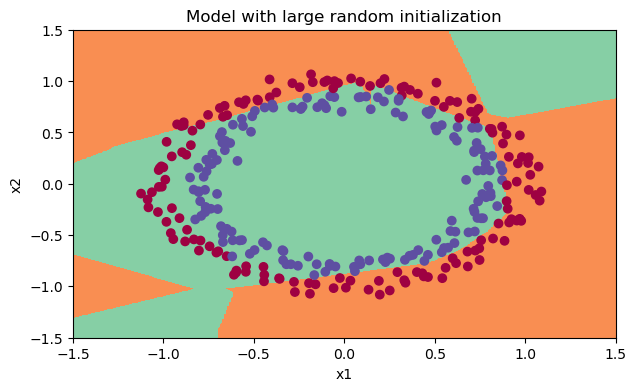

In [24]:
plt.title("Model with large random initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
init_utils.plot_decision_boundary(
    lambda x: init_utils.predict_dec(parameters, x.T), train_X, train_Y)

⑧ 我们可以看到误差开始很高。这是因为由于具有较大的随机权重，最后一个激活(sigmoid)输出的结果非常接近于 0 或 1，而当它出现错误时，它会导致非常高的损失。

⑨ 初始化参数如果没有很好地话会导致梯度消失、爆炸，这也会减慢优化算法。如果我们对这个网络进行更长时间的训练，我们将看到更好的结果，但是使用过大的随机数初始化会减慢优化的速度。

⑩ 总而言之，将权重初始化为非常大的时候其实效果并不好，下面我们试试小一点的参数值。


总结：

1. 将权重初始化为非常大的随机值效果不佳。
2. 初始化为较小的随机值会更好。重要的问题是：这些随机值应为多小？让我们在下一部分中找到答案！


### 3.2.3 抑梯度异常初始化


① 最后，让我们尝试一下“He 初始化”，该名称以 He 等人的名字命名（类似于“Xavier 初始化”，但 Xavier 初始化使用比例因子 sqrt(1./layers_dims[l-1])来表示权重 ，而 He 初始化使用 sqrt(2./layers_dims[l-1])）。

② note：此函数类似于先前的 initialize_parameters_random(...)。 唯一的不同是，无需将 np.random.randn(..,..)乘以 10，而是将其乘以$\sqrt{\frac{2}{\text{dimension of the previous layer}}}$，这是 He 初始化建议使用的 ReLU 激活层。


In [25]:
def initialize_parameters_he(layers_dims):
    """
    参数：
        layers_dims - 列表，模型的层数和对应每一层的节点的数量
    返回
        parameters - 包含了所有W和b的字典
            W1 - 权重矩阵，维度为（layers_dims[1], layers_dims[0]）
            b1 - 偏置向量，维度为（layers_dims[1],1）
            ···
            WL - 权重矩阵，维度为（layers_dims[L], layers_dims[L -1]）
            b1 - 偏置向量，维度为（layers_dims[L],1）
    """

    np.random.seed(3)      # 指定随机种子
    parameters = {}
    L = len(layers_dims)   # 层数

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l],
                                                   layers_dims[l - 1]) * np.sqrt(2 / layers_dims[l - 1])
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))

        # 使用断言确保我的数据格式是正确的
        assert (parameters["W" + str(l)].shape ==
                (layers_dims[l], layers_dims[l-1]))
        assert (parameters["b" + str(l)].shape == (layers_dims[l], 1))

    return parameters

③ 我们来测试一下这个函数：


In [26]:
print("======我们来测试一下======")
parameters = initialize_parameters_he([2, 4, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

======我们来测试一下======
W1 = [[ 1.78862847  0.43650985]
 [ 0.09649747 -1.8634927 ]
 [-0.2773882  -0.35475898]
 [-0.08274148 -0.62700068]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.03098412 -0.33744411 -0.92904268  0.62552248]]
b2 = [[0.]]


④ 这样我们就基本把参数 W 初始化到了 1 附近，我们来实际运行一下看看：

⑤ 运行以下代码，使用 He 初始化并迭代 14,000 次以训练你的模型。


======我们来测试一下======
第0次迭代，成本值为：0.8830537463419761
第1000次迭代，成本值为：0.6879825919728063
第2000次迭代，成本值为：0.6751286264523371
第3000次迭代，成本值为：0.6526117768893807
第4000次迭代，成本值为：0.6082958970572938
第5000次迭代，成本值为：0.5304944491717495
第6000次迭代，成本值为：0.4138645817071795
第7000次迭代，成本值为：0.3117803464844441
第8000次迭代，成本值为：0.23696215330322562
第9000次迭代，成本值为：0.18597287209206836
第10000次迭代，成本值为：0.15015556280371808
第11000次迭代，成本值为：0.12325079292273548
第12000次迭代，成本值为：0.09917746546525934
第13000次迭代，成本值为：0.08457055954024276
第14000次迭代，成本值为：0.07357895962677362


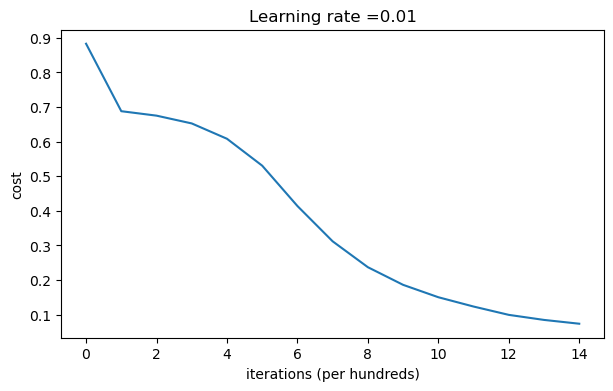

训练集:
Accuracy: 0.9933333333333333
测试集:
Accuracy: 0.96


In [27]:
print("======我们来测试一下======")
parameters = model(train_X, train_Y, initialization="he", is_polt=True)
print("训练集:")
predictions_train = init_utils.predict(train_X, train_Y, parameters)
print("测试集:")
init_utils.predictions_test = init_utils.predict(test_X, test_Y, parameters)

⑥ 我们可以看到误差越来越小，我们来绘制一下预测的情况：


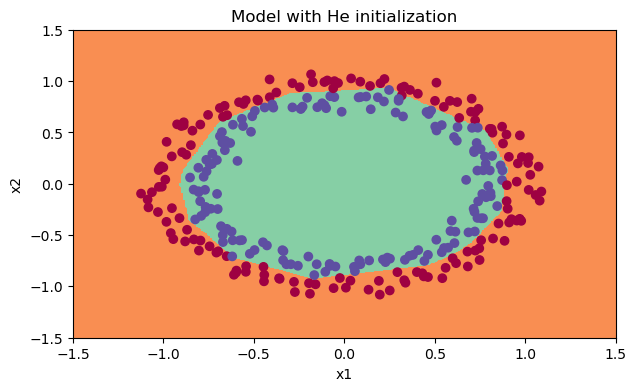

In [28]:
plt.title("Model with He initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
init_utils.plot_decision_boundary(
    lambda x: init_utils.predict_dec(parameters, x.T), train_X, train_Y)

⑦ 初始化的模型将蓝色和红色的点在少量的迭代中很好地分离出来


## 3.3 总结


① 我们已经学习了三种不同类型的初始化方法。对于相同的迭代次数和超参数，三种结果比较为：


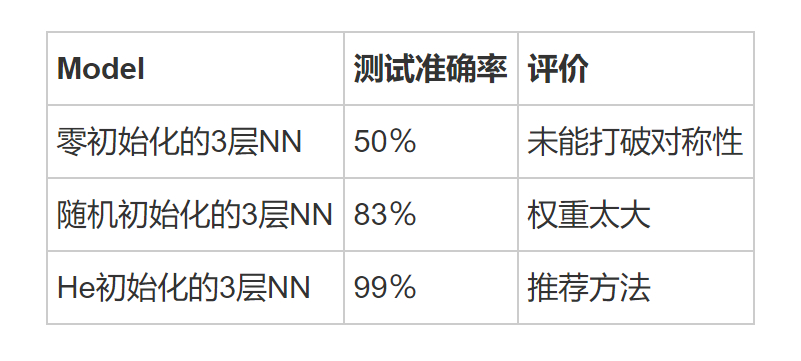


此作业中应记住的内容：

1. 不同的初始化方法可能导致性能最终不同。
2. 随机初始化有助于打破对称，使得不同隐藏层的单元可以学习到不同的参数。
3. 初始化时，初始值不宜过大。
4. He 初始化搭配 ReLU 激活函数常常可以得到不错的效果。


② 在深度学习中，如果数据集没有足够大的话，可能会导致一些过拟合的问题。过拟合导致的结果就是在训练集上有着很高的精确度，但是在遇到新的样本时，精确度下降会很严重。为了避免过拟合的问题，接下来我们要讲解的方式就是正则化。


# **_深度神经网络的正则化_**


# 0. 要解决的问题


① 深度学习模型具有很高的灵活性和能力，如果训练数据集不够大，将会造成一个严重的问题--过拟合。

② 尽管它在训练集上效果很好，但是学到的网络不能应用到测试集中！

③ 本周作业你将学习： 在深度学习模型中使用正则化。


问题描述：假设你现在是一个 AI 专家，你需要设计一个模型，可以用于推荐在足球场中守门员将球发至哪个位置可以让本队的球员抢到球的可能性更大。说白了，实际上就是一个二分类，一半是己方抢到球，一半就是对方抢到球，我们来看一下这个图：


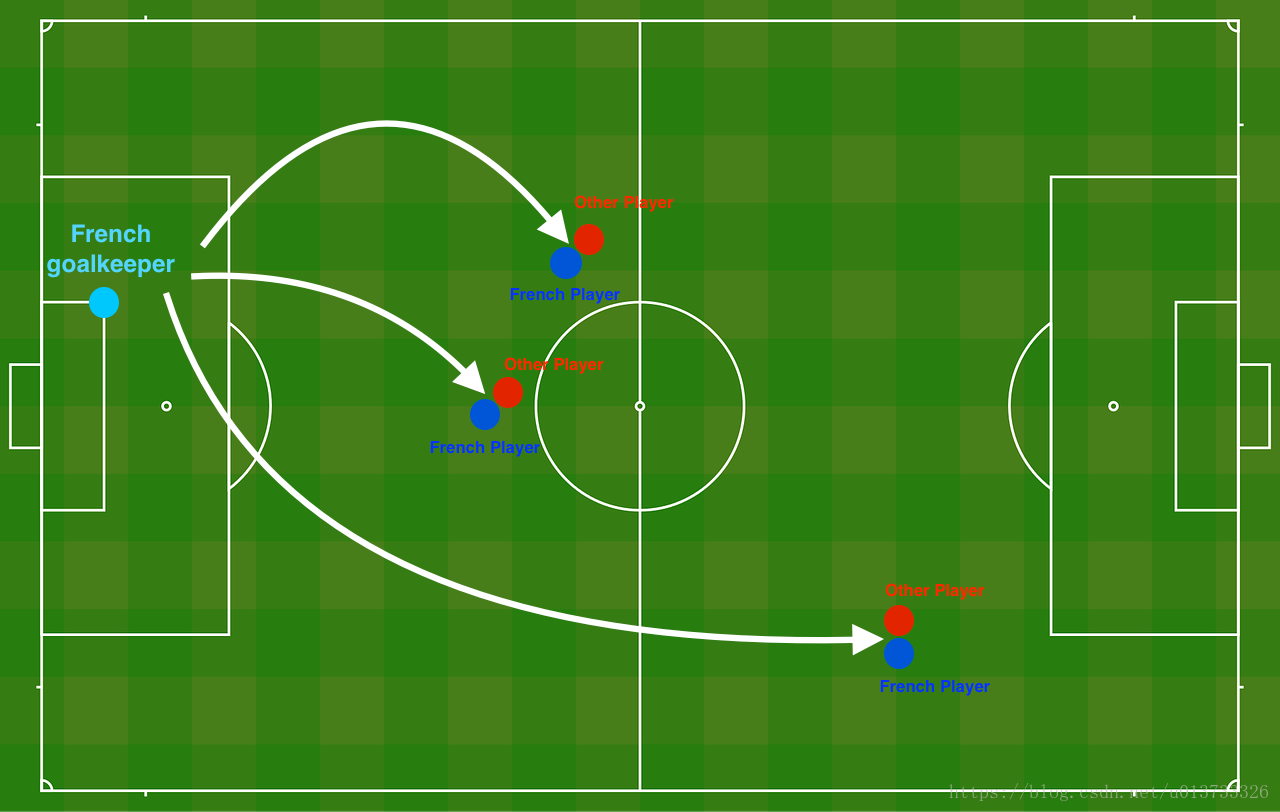


① 数据中每个点对应于足球场上的位置，在该位置上，法国守门员从足球场左侧射出球后，足球运动员用他/她的头部击中了球。

1. 如果圆点为蓝色，则表示法国球员设法用头部将球击中
2. 如果圆点为红色，则表示另一支球队的球员用头撞球

你的目标：运用深度学习模型预测守门员应将球踢到球场上的位置。

数据集分析：该数据集含有噪声，但看起来一条将左上半部分（蓝色）与右下半部分（红色）分开的对角线会很比较有效。

② 你将首先尝试非正则化模型。然后学习如何对其进行正则化，并决定选择哪种模型来解决法国足球公司的问题。


# 1. 导入库


① 首先导入要使用的包。


In [29]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from andrew_dl.l2.l2w1.reg_utils import *
import sklearn
import sklearn.datasets
# from testCase import *

%matplotlib inline

# 设置 plot 的默认大小
plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 2. 读取并绘制数据


In [30]:
import importlib
importlib.reload(reg_utils)

<module 'andrew_dl.l2.l2w1.reg_utils' from 'd:\\ai\\cv\\I-AccumulateMore-CV\\andrew_dl\\l2\\l2w1\\reg_utils.py'>

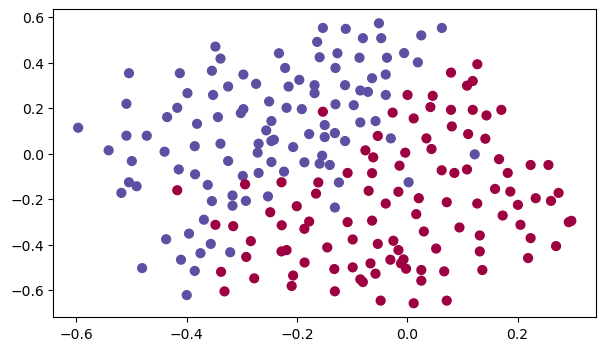

In [31]:
train_X, train_Y, test_X, test_Y = load_2D_dataset(is_plot=True)

① 每一个点代表球落下的可能的位置，蓝色代表己方的球员会抢到球，红色代表对手的球员会抢到球，我们要做的就是使用模型来画出一条线，来找到适合我方球员能抢到球的位置。

② 我们要做以下三件事，来对比出不同的模型的优劣：

1. 不使用正则化
2. 使用正则化

- 2.1 使用 L2 正则化
- 2.2 使用随机节点删除


# 3. 正则化模型简介


① 我们来看一下我们的模型：

1. 正则化模式 - 将 lambd 输入设置为非零值。 我们使用“lambd”而不是“lambda”，因为“lambda”是 Python 中的保留关键字。
2. 随机删除节点 - 将 keep_prob 设置为小于 1 的值。


① 你将使用以下神经网络（已为你实现），可以如下使用此模型：

1. 在 regularization mode 中，通过 lambd 将输入设置为非零值。我们使用 lambd 代替 lambda，因为 lambda 是 Python 中的保留关键字。
2. 在 dropout mode 中，将 keep_prob 设置为小于 1 的值

② 首先，你将尝试不进行任何正则化的模型。然后，你将实现：

1. L2 正则化 函数：compute_cost_with_regularization()和 backward_propagation_with_regularization()
2. Dropout 函数：forward_propagation_with_dropout()和 backward_propagation_with_dropout()

③ 在每个部分中，你都将使用正确的输入来运行此模型，以便它调用已实现的函数。查看以下代码以熟悉该模型。


In [32]:
def model(X, Y, learning_rate=0.3, num_iterations=30000, print_cost=True, is_plot=True, lambd=0, keep_prob=1):
    """
    实现一个三层的神经网络：LINEAR ->RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID
    参数：
        X - 输入的数据，维度为(2, 要训练/测试的数量)
        Y - 标签，【0(蓝色) | 1(红色)】，维度为(1，对应的是输入的数据的标签)
        learning_rate - 学习速率
        num_iterations - 迭代的次数
        print_cost - 是否打印成本值，每迭代10000次打印一次，但是每1000次记录一个成本值
        is_polt - 是否绘制梯度下降的曲线图
        lambd - 正则化的超参数，实数
        keep_prob - 随机删除节点的概率
    返回
        parameters - 学习后的参数
    """
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 20, 3, 1]
    # 初始化参数
    parameters = initialize_parameters(layers_dims)
    # 开始学习
    for i in range(0, num_iterations):
        # 前向传播
        # 是否随机删除节点
        if keep_prob == 1:
            # 不随机删除节点
            a3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            # 随机删除节点
            a3, cache = forward_propagation_with_dropout(
                X, parameters, keep_prob)
        else:
            print("keep_prob参数错误！程序退出。")
            exit
        # 计算成本
        # 是否使用二范数
        if lambd == 0:
            # 不使用 L2 正则化
            cost = compute_cost(a3, Y)
        else:
            # 使用 L2 正则化
            cost = compute_cost_with_regularization(a3, Y, parameters, lambd)
        # 反向传播
        # 可以同时使用 L2 正则化和随机删除节点，但是本次实验不同时使用。
        assert (lambd == 0 or keep_prob == 1)
        # 两个参数的使用情况
        if (lambd == 0 and keep_prob == 1):
            # 不使用 L2 正则化和不使用随机删除节点
            grads = backward_propagation(X, Y, cache)
        elif lambd != 0:
            # 使用 L2 正则化，不使用随机删除节点
            grads = backward_propagation_with_regularization(
                X, Y, cache, lambd)
        elif keep_prob < 1:
            # 使用随机删除节点，不使用 L2 正则化
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)
        # 更新参数
        parameters = update_parameters(parameters, grads, learning_rate)
        # 记录并打印成本
        if i % 1000 == 0:
            # 记录成本
            costs.append(cost)
            if (print_cost and i % 10000 == 0):
                # 打印成本
                print("第" + str(i) + "次迭代，成本值为：" + str(cost))
    # 是否绘制成本曲线图
    if is_plot:
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (x1,000)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()
    # 返回学习后的参数
    return parameters

④ 我们来先看一下不使用正则化下模型的效果。


## 3.1 不使用正则化


① 让我们在不进行任何正则化的情况下训练模型，并观察训练/测试集的准确性。


======我们来测试一下======
第0次迭代，成本值为：0.6557412523481002
第10000次迭代，成本值为：0.16329987525724204
第20000次迭代，成本值为：0.13851642423284527


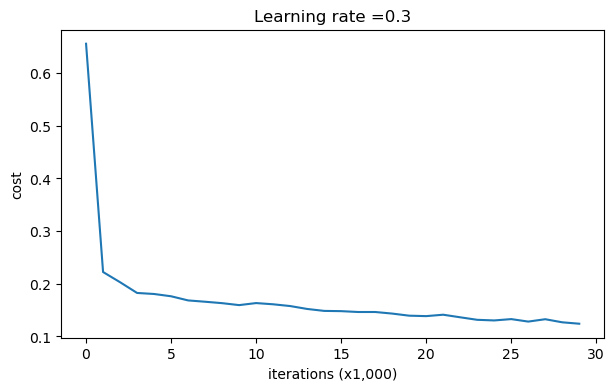

训练集:
Accuracy: 0.9478672985781991
测试集:
Accuracy: 0.915


In [33]:
print("======我们来测试一下======")
parameters = model(train_X, train_Y, is_plot=True)
print("训练集:")
predictions_train = predict(train_X, train_Y, parameters)
print("测试集:")
predictions_test = predict(test_X, test_Y, parameters)

② 我们可以看到，对于训练集，精确度为 94%；而对于测试集，精确度为 91.5%。接下来，我们将分割曲线画出来。


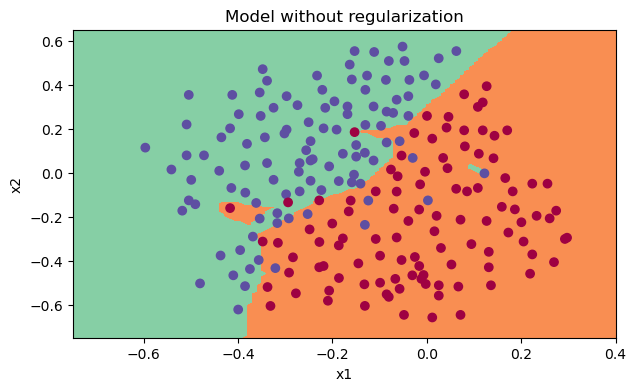

In [34]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(
    parameters, x.T), train_X, train_Y)

③ 从图中可以看出，在无正则化时，分割曲线有了明显的过拟合特性。接下来，我们使用 L2 正则化。


## 3.2 使用正则化


① 避免过度拟合的标准方法称为 L2 正则化，它适当修改你的成本函数，我们从原来的成本函数(1)到现在的函数(2)：

$$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} \tag{1}$$

$$J_{regularized} = \small \underbrace{-\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} }_\text{cross-entropy cost} \\+ \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2} }_\text{L2 regularization cost} \tag{2}$$

② 让我们修改损失并观察结果。


③ 计算$\sum\limits_k\sum\limits_j W_{k,j}^{[l]2}$的代码为：np.sum(np.square(Wl))

④ 需要注意的是在前项传播中我们对$W^{[1]}$，$W^{[2]}$，$W^{[3]}$这三个项进行操作，将三个项相加并乘以$\frac{1}{m}\frac{\lambda}{2}$。

⑤ 在后向传播中，使用$\frac{d}{dW} ( \frac{1}{2}\frac{\lambda}{m} W^2) = \frac{\lambda}{m} W$计算梯度。


⑥ 因为你更改了损失，所以还必须更改反向传播！ 必须针对新损失函数计算所有梯度。

⑦ 练习：实现正则化后的反向传播。更改仅涉及 dW1，dW2 和 dW3。对于每一个，你必须添加正则化项的梯度$(\frac{d}{dW} ( \frac{1}{2}\frac{\lambda}{m}  W^2) = \frac{\lambda}{m} W)$。


In [35]:
def compute_cost_with_regularization(A3, Y, parameters, lambd):
    """
    实现公式2的L2正则化计算成本
    参数：
        A3 - 正向传播的输出结果，维度为（输出节点数量，训练/测试的数量）
        Y - 标签向量，与数据一一对应，维度为(输出节点数量，训练/测试的数量)
        parameters - 包含模型学习后的参数的字典
    返回：
        cost - 使用公式2计算出来的正则化损失的值
    """
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]
    cross_entropy_cost = compute_cost(A3, Y)
    L2_regularization_cost = lambd * \
        (np.sum(np.square(W1)) + np.sum(np.square(W2)) +
         np.sum(np.square(W3))) / (2 * m)
    cost = cross_entropy_cost + L2_regularization_cost
    return cost
# 当然，因为改变了成本函数，我们也必须改变向后传播的函数，
# 所有的梯度都必须根据这个新的成本值来计算。


def backward_propagation_with_regularization(X, Y, cache, lambd):
    """
    实现我们添加了L2正则化的模型的后向传播。
    参数：
        X - 输入数据集，维度为（输入节点数量，数据集里面的数量）
        Y - 标签，维度为（输出节点数量，数据集里面的数量）
        cache - 来自forward_propagation（）的cache输出
        lambda - regularization超参数，实数
    返回：
        gradients - 一个包含了每个参数、激活值和预激活值变量的梯度的字典
    """
    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache
    dZ3 = A3 - Y
    dW3 = (1 / m) * np.dot(dZ3, A2.T) + ((lambd * W3) / m)
    db3 = (1 / m) * np.sum(dZ3, axis=1, keepdims=True)
    dA2 = np.dot(W3.T, dZ3)
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = (1 / m) * np.dot(dZ2, A1.T) + ((lambd * W2) / m)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = (1 / m) * np.dot(dZ1, X.T) + ((lambd * W1) / m)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3, "dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}
    return gradients

⑧ 我们来直接放到模型中跑一下：


In [36]:
A3, Y_assess, parameters = compute_cost_with_regularization_test_case()
print("cost = " + str(compute_cost_with_regularization(A3,
      Y_assess, parameters, lambd=0.1)))

cost = 1.7864859451590758


In [37]:
X_assess, Y_assess, cache = backward_propagation_with_regularization_test_case()
grads = backward_propagation_with_regularization(
    X_assess, Y_assess, cache, lambd=0.7)
print("dW1 = " + str(grads["dW1"]))
print("dW2 = " + str(grads["dW2"]))
print("dW3 = " + str(grads["dW3"]))

dW1 = [[-0.25604646  0.12298827 -0.28297129]
 [-0.17706303  0.34536094 -0.4410571 ]]
dW2 = [[ 0.79276486  0.85133918]
 [-0.0957219  -0.01720463]
 [-0.13100772 -0.03750433]]
dW3 = [[-1.77691347 -0.11832879 -0.09397446]]


⑨ 现在让我们使用 L2 正则化$(\lambda = 0.7)$运行的模型。model（）函数将调用：

1. compute_cost_with_regularization 代替 compute_cost
2. backward_propagation_with_regularization 代替 backward_propagation


第0次迭代，成本值为：0.6974484493131264
第10000次迭代，成本值为：0.2684918873282239
第20000次迭代，成本值为：0.2680916337127301


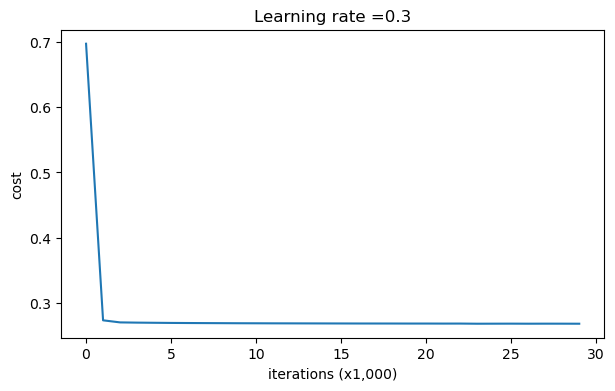

使用正则化，训练集:
Accuracy: 0.9383886255924171
使用正则化，测试集:
Accuracy: 0.93


In [38]:
parameters = model(train_X, train_Y, lambd=0.7, is_plot=True)
print("使用正则化，训练集:")
predictions_train = predict(train_X, train_Y, parameters)
print("使用正则化，测试集:")
predictions_test = predict(test_X, test_Y, parameters)

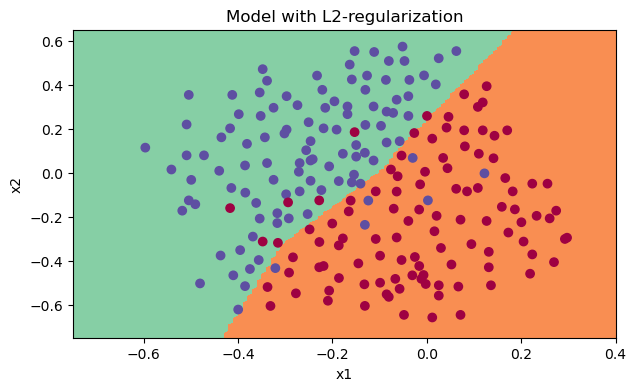

In [39]:
plt.title("Model with L2-regularization")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(
    parameters, x.T), train_X, train_Y)

# 4. Dropout


① Dropout 是广泛用于深度学习的正则化技术。它会在每次迭代中随机关闭一些神经元。
观看这两个 video，看看这它是什么意思！

② 要了解 Dropout，可以思考与朋友进行以下对话：

- 朋友：“为什么你需要所有神经元来训练你的网络以分类图像？”。
- 你：“因为每个神经元都有权重，并且可以学习图像的特定特征/细节/形状。我拥有的神经元越多，模型学习的特征就越丰富！”
- 朋友：“我知道了，但是你确定你的神经元学习的是不同的特征而不是全部相同的特征吗？”
- 你：“这是个好问题……同一层中的神经元实际上并不关联。应该绝对有可能让他们学习相同的图像特征/形状/形式/细节...这是多余的。为此应该有一个解决方案。”


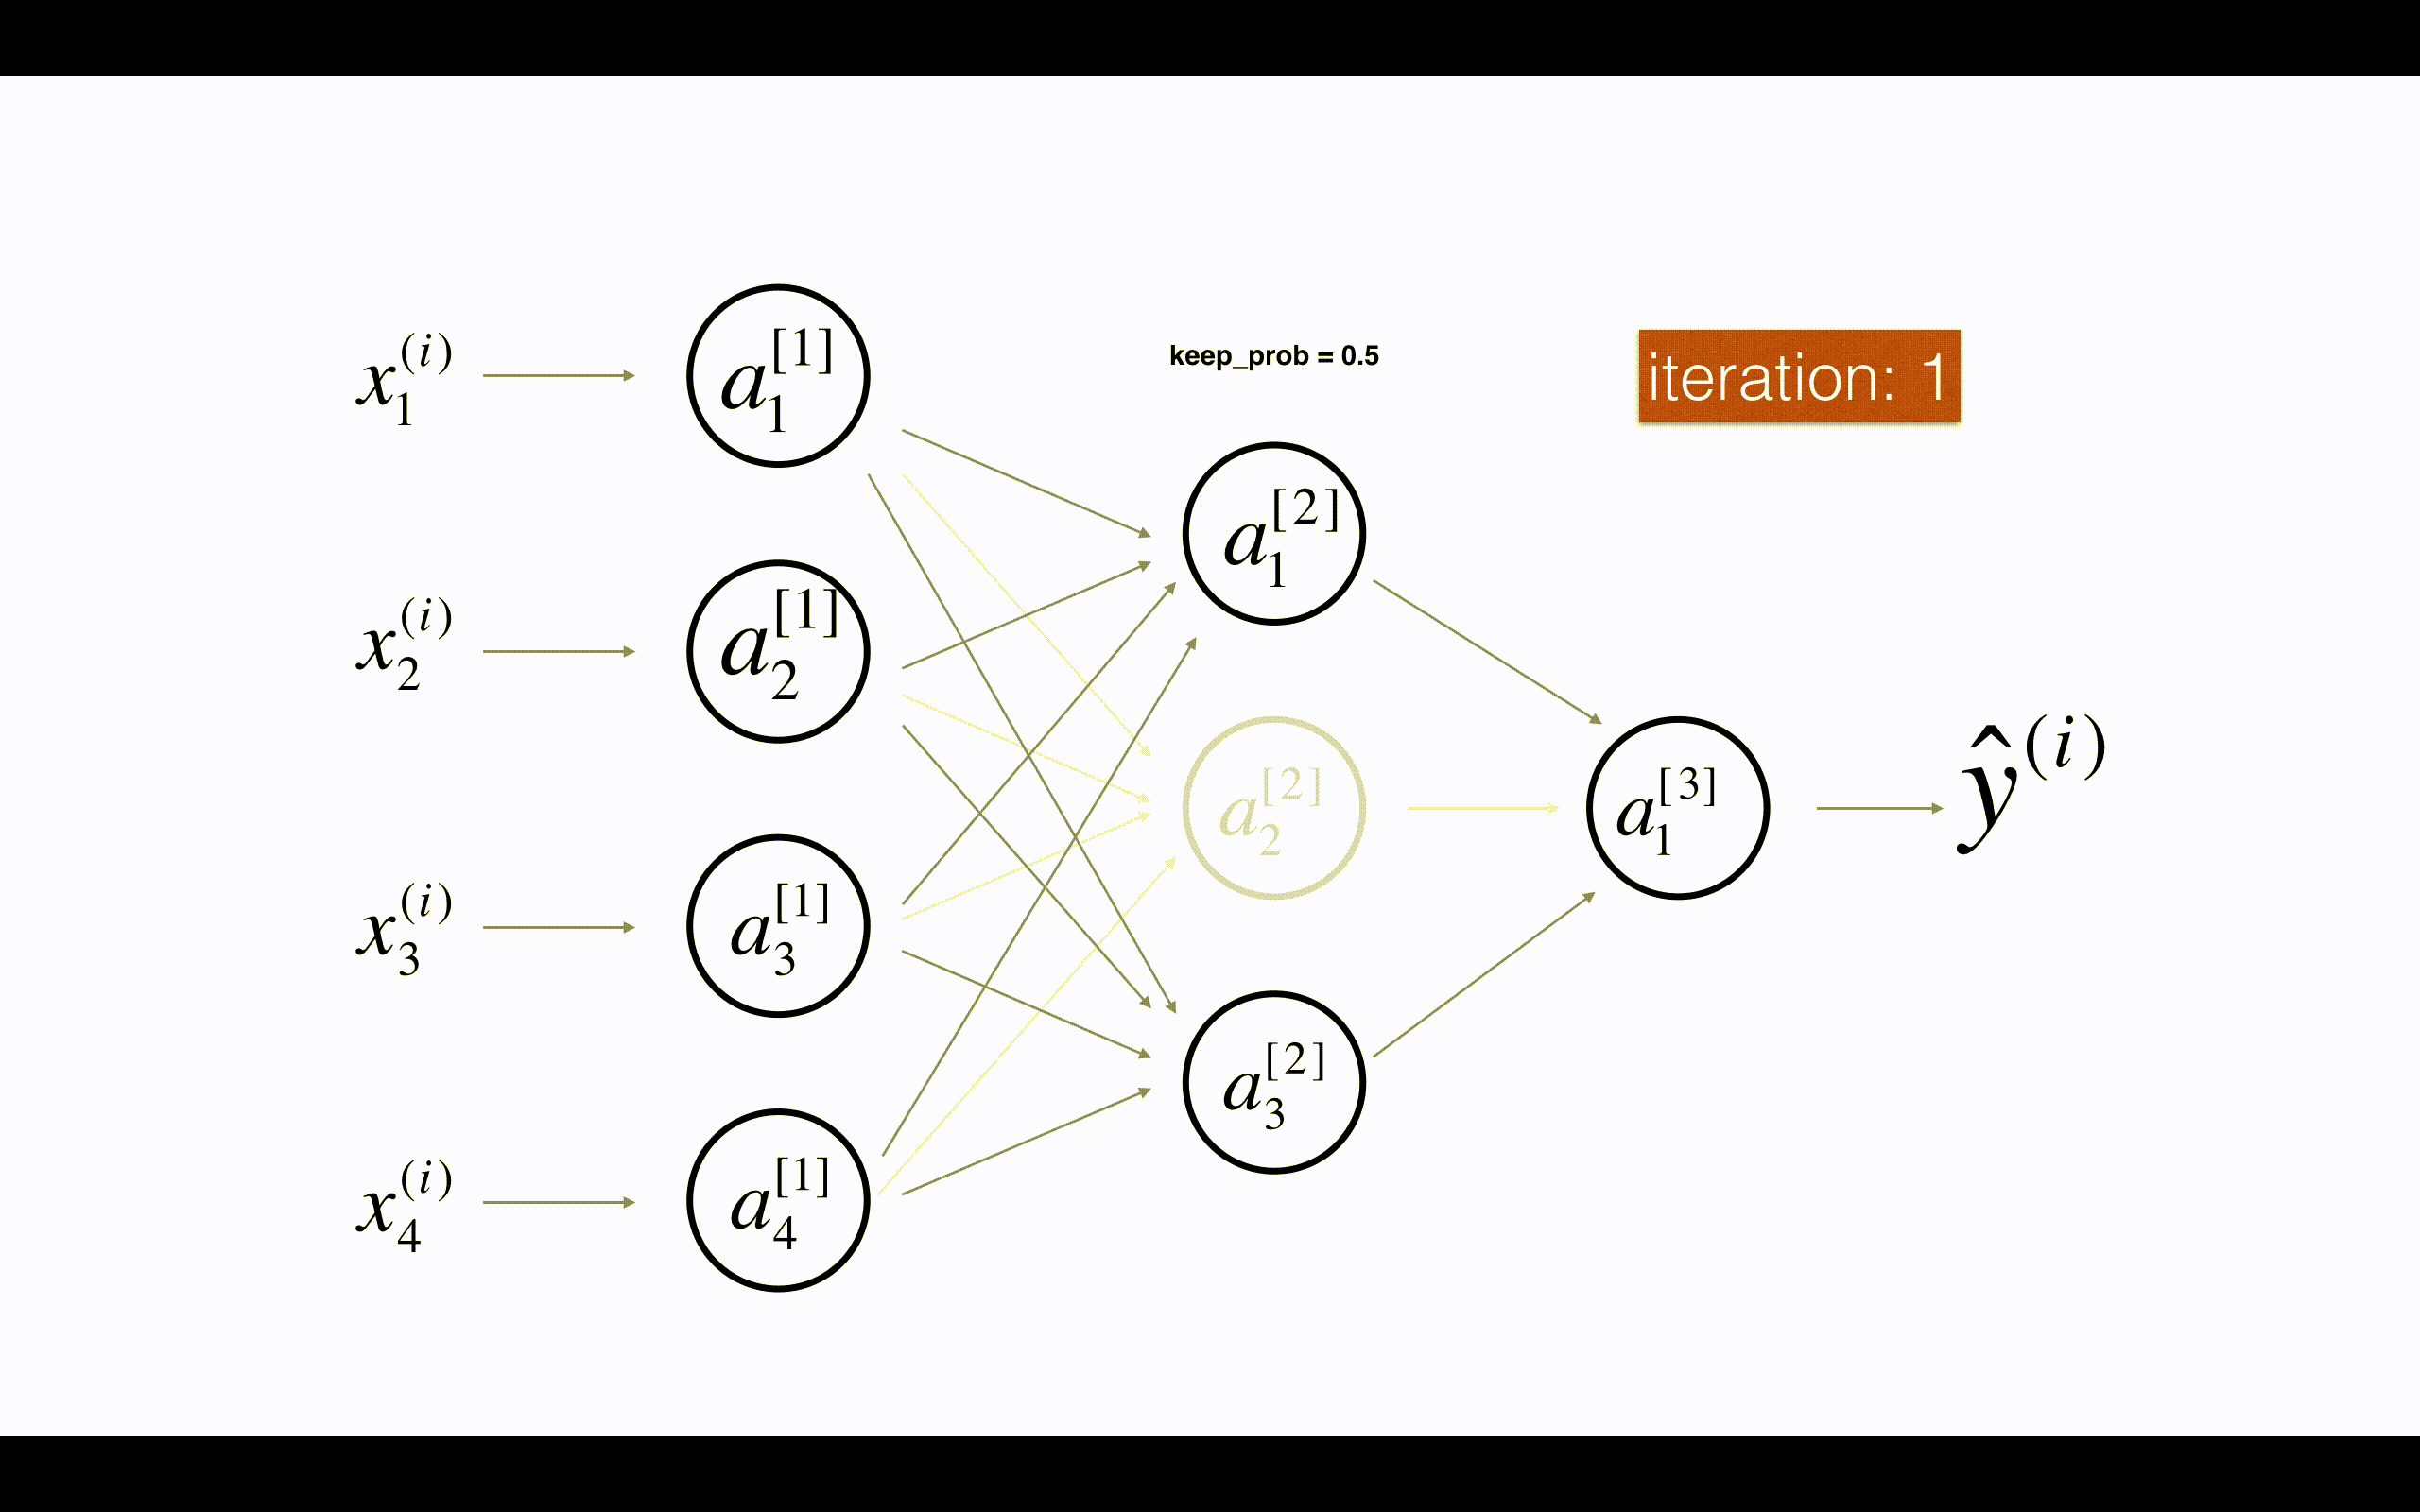


③ 在每次迭代中，你以概率$1 - keep\_prob$或以概率$keep\_prob$（此处为 50％）关闭此层的每个神经元。关闭的神经元对迭代的正向和反向传播均无助于训练。


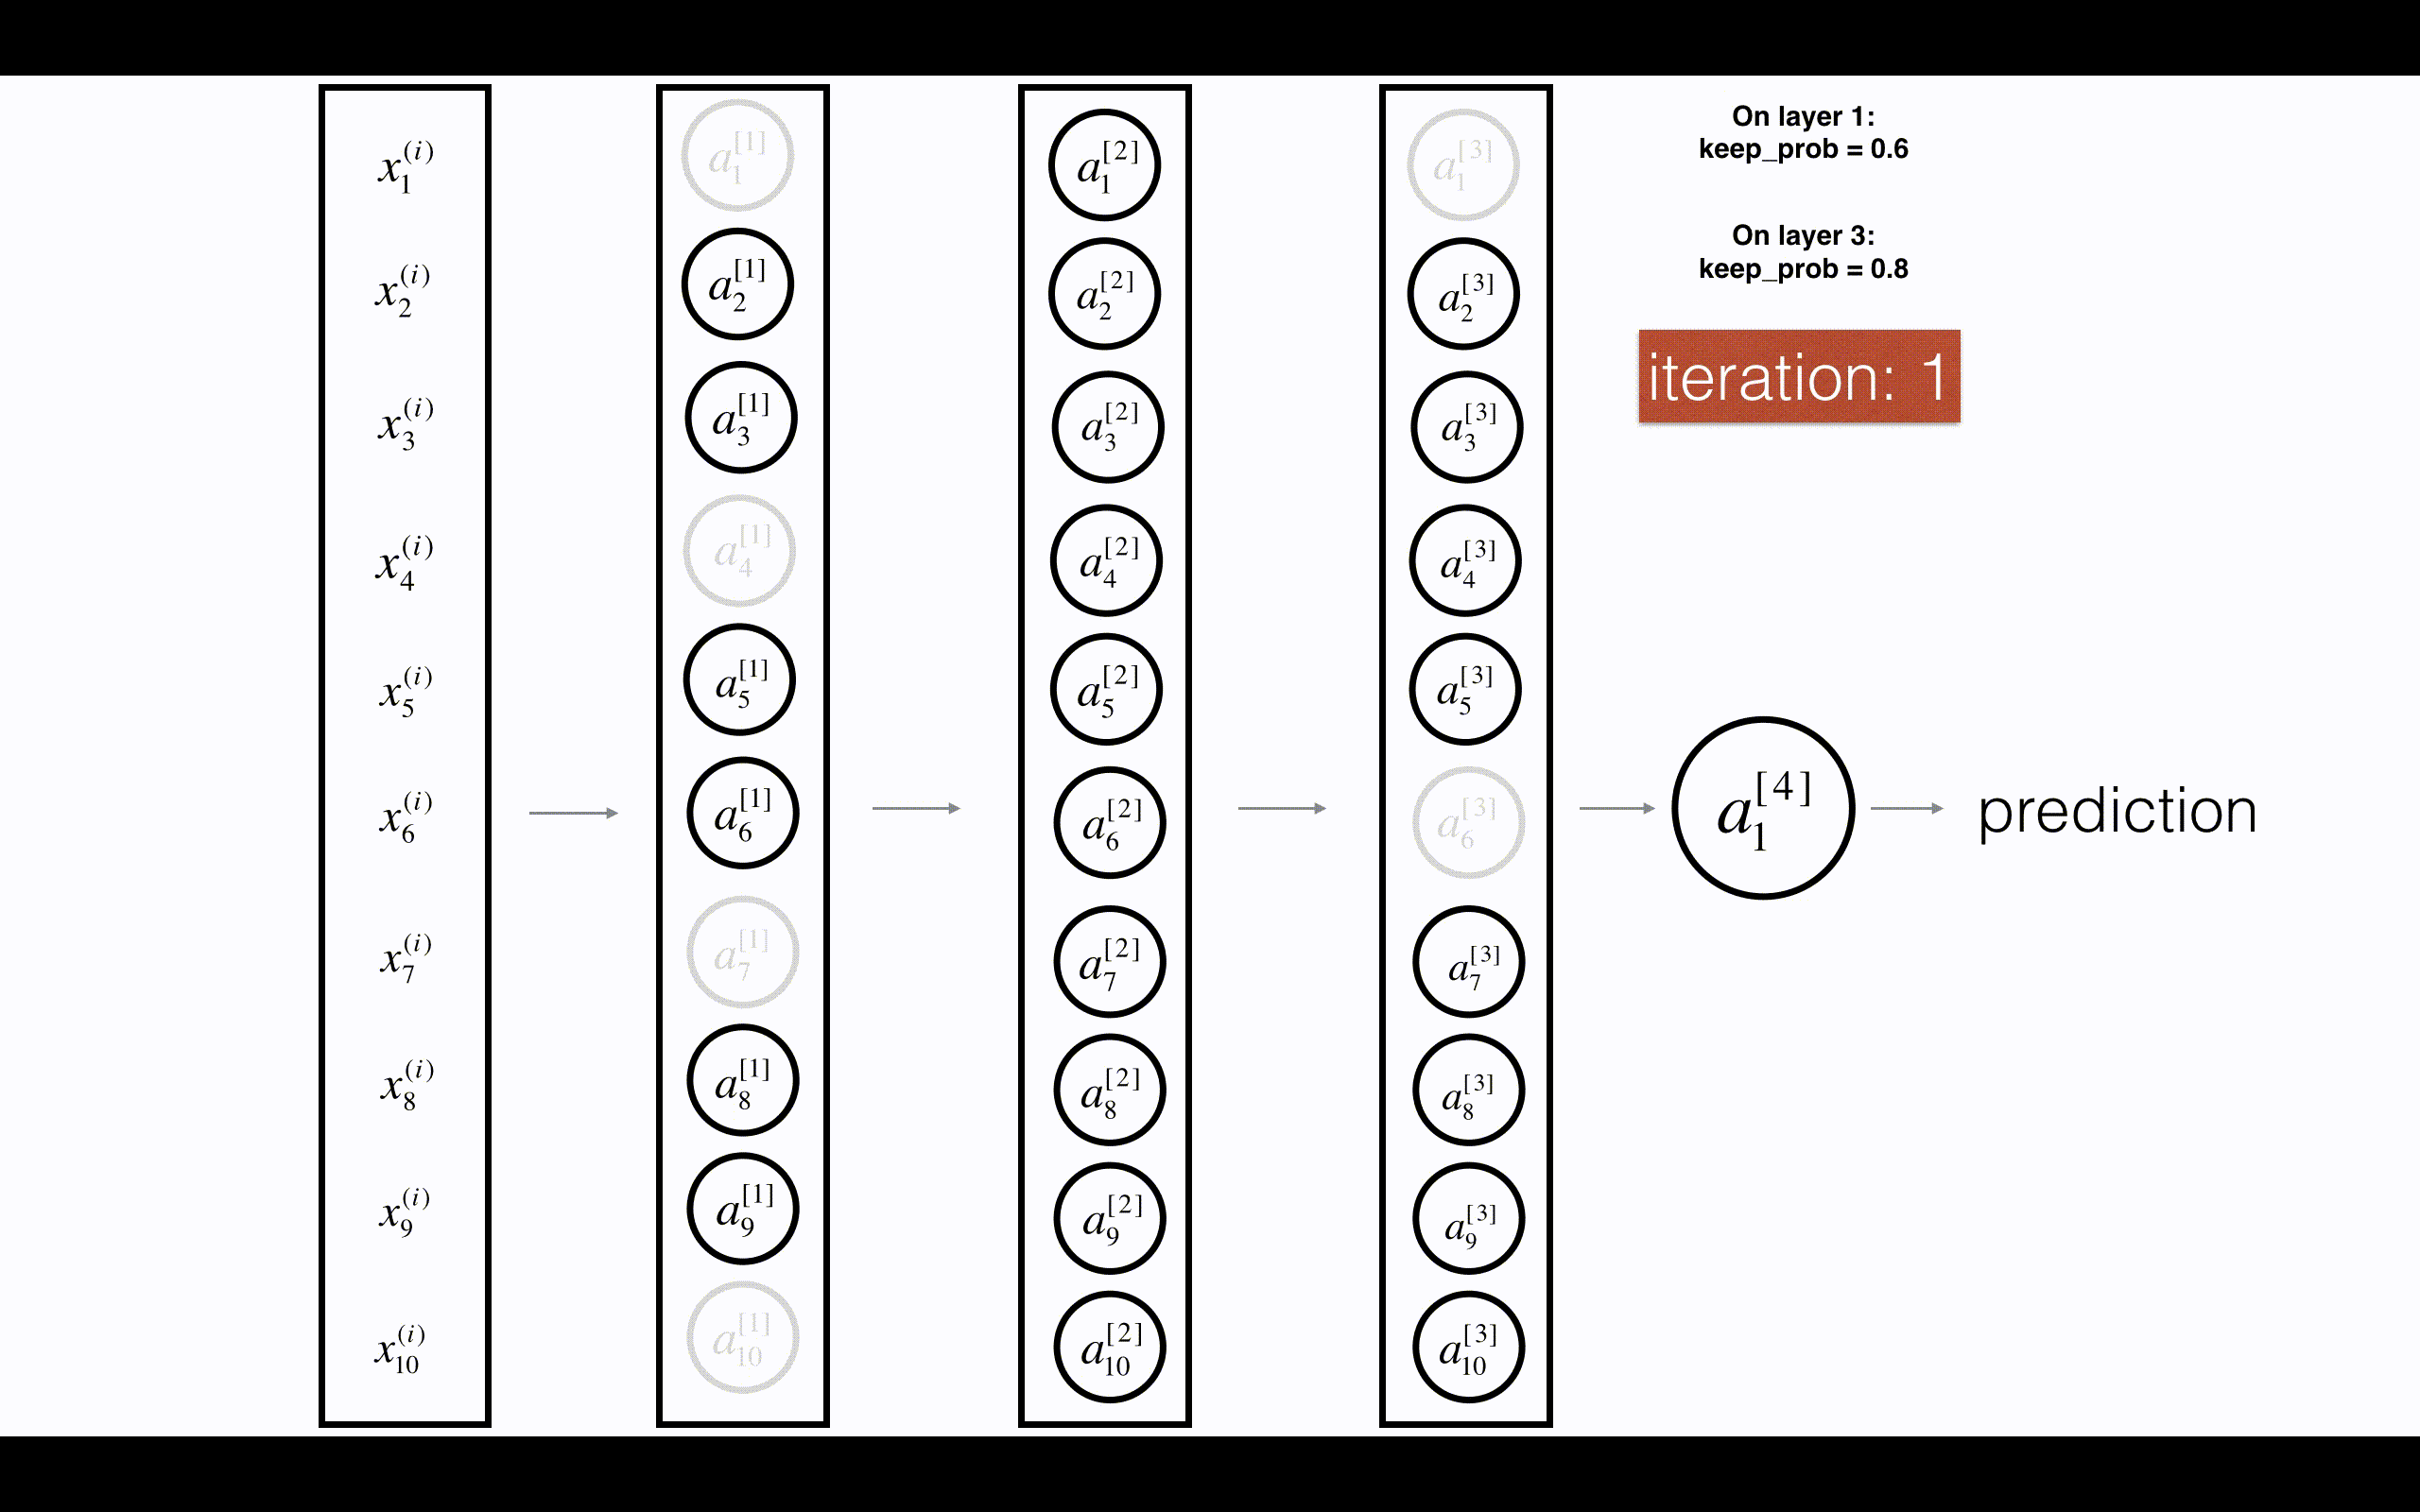


④ $1^{st}$层：我们平均关闭了 40％的神经元。

⑤ $3^{rd}$层：我们平均关闭了 20％的神经元。

⑥ 当你关闭某些神经元时，实际上是在修改模型。

⑦ Dropout 背后的想法是，在每次迭代中，你将训练仅使用神经元子集的不同模型。

⑧ 通过 Dropout，你的神经元对另一种特定神经元的激活变得不那么敏感，因为另一神经元可能随时关闭。


## 4.1 带有 Dropout 的正向传播


练习：实现带有 Dropout 的正向传播。你正在使用 3 层的神经网络，并将为第一和第二隐藏层添加 Dropout。我们不会将 Dropout 应用于输入层或输出层。

说明：关闭第一层和第二层中的某些神经元。为此，将执行 4 个步骤：

1. 在讲座中，我们讨论了使用 np.random.rand（）创建与$a^{[1]}$形状相同的变量$d^{[1]}$的方法，以随机获取 0 到 1 之间的数。在这里，你将使用向量化的实现，创建一个与$A^{[1]}$的矩阵维度相同的随机矩阵$D^{[1]} = [d^{[1](1)} d^{[1](2)} ... d^{[1](m)}]$
2. 通过对$D^{[1]}$中的值进行阈值设置，将$D^{[1]}$的每个条目设置为 0（概率为 1-keep_prob）或 1（概率为 keep_prob）。提示：将矩阵 X 的所有条目设置为 0（如果概率小于 0.5）或 1（如果概率大于 0.5），则可以执行：X = (X < 0.5)。注意 0 和 1 分别对应 False 和 True。
3. 将$A^{[1]}$设置为$A^{[1]} * D^{[1]}$（关闭一些神经元）。你可以将$D^{[1]}$视为掩码，这样当它与另一个矩阵相乘时，关闭某些值。
4. 将$A^{[1]}$除以 keep_prob。通过这样做，你可以确保损失结果仍具有与 dropout 相同的期望值。（此技术也称为反向 dropout）


In [ ]:
def forward_propagation_with_dropout(X, parameters, keep_prob=0.5):
    """
    Implements the forward propagation: LINEAR -> RELU + DROPOUT -> LINEAR -> RELU + DROPOUT -> LINEAR -> SIGMOID.

    Arguments:
    X -- input dataset, of shape (2, number of examples)
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3":
                    W1 -- weight matrix of shape (20, 2)
                    b1 -- bias vector of shape (20, 1)
                    W2 -- weight matrix of shape (3, 20)
                    b2 -- bias vector of shape (3, 1)
                    W3 -- weight matrix of shape (1, 3)
                    b3 -- bias vector of shape (1, 1)
    keep_prob - probability of keeping a neuron active during drop-out, scalar

    Returns:
    A3 -- last activation value, output of the forward propagation, of shape (1,1)
    cache -- tuple, information stored for computing the backward propagation
    """

    np.random.seed(1)

    # retrieve parameters
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    # START CODE HERE ### (approx. 4 lines)         # Steps 1-4 below correspond to the Steps 1-4 described above.
    # Step 1: initialize matrix D1 = np.random.rand(..., ...)
    D1 = np.random.rand(A1.shape[0], A1.shape[1])
    # Step 2: convert entries of D1 to 0 or 1 (using keep_prob as the threshold)
    D1 = D1 < keep_prob
    # Step 3: shut down some neurons of A1
    A1 = A1 * D1
    # Step 4: scale the value of neurons that haven't been shut down
    A1 = A1 / keep_prob
    ### END CODE HERE ###
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)
    # START CODE HERE ### (approx. 4 lines)
    # Step 1: initialize matrix D2 = np.random.rand(..., ...)
    D2 = np.random.rand(A2.shape[0], A2.shape[1])
    # Step 2: convert entries of D2 to 0 or 1 (using keep_prob as the threshold)
    D2 = D2 < keep_prob
    # Step 3: shut down some neurons of A2
    A2 = A2 * D2
    # Step 4: scale the value of neurons that haven't been shut down
    A2 = A2 / keep_prob
    ### END CODE HERE ###
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3)

    return A3, cache

In [ ]:
X_assess, parameters = forward_propagation_with_dropout_test_case()

A3, cache = forward_propagation_with_dropout(
    X_assess, parameters, keep_prob=0.7)
print("A3 = " + str(A3))

A3 = [[0.36974721 0.00305176 0.04565099 0.49683389 0.36974721]]


## 4.2 带有 dropout 的反向传播


练习：实现带有 dropout 的反向传播。和之前一样，训练一个 3 层的网络。使用存储在缓存中的掩码$D^{[1]}$和$D^{[2]}$，添加 dropout 到第一和第二个隐藏层。

说明：
带有 dropout 的反向传播实现上非常容易。你将必须执行 2 个步骤：

1. 你先前通过在 A1 上应用掩码$D^{[1]}$来关闭正向传播过程中的某些神经元。在反向传播中，你将必须将相同的掩码$D^{[1]}$重新应用于 dA1 来关闭相同的神经元。
2. 在正向传播过程中，你已将 A1 除以 keep_prob。 因此，在反向传播中，必须再次将 dA1 除以 keep_prob（计算的解释是，如果$A^{[1]}$被 keep_prob 缩放，则其派生的$dA^{[1]}$也由相同的 keep_prob 缩放）。


In [ ]:
def backward_propagation_with_dropout(X, Y, cache, keep_prob):
    """
    Implements the backward propagation of our baseline model to which we added dropout.

    Arguments:

    X -- input dataset, of shape (2, number of examples)
    Y -- "true" labels vector, of shape (output size, number of examples)
    cache -- cache output from forward_propagation_with_dropout()
    keep_prob - probability of keeping a neuron active during drop-out, scalar

    Returns:
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables
    """

    m = X.shape[1]
    (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = 1./m * np.dot(dZ3, A2.T)
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims=True)
    dA2 = np.dot(W3.T, dZ3)
    # START CODE HERE ### (≈ 2 lines of code)
    # Step 1: Apply mask D2 to shut down the same neurons as during the forward propagation
    dA2 = dA2 * D2
    # Step 2: Scale the value of neurons that haven't been shut down
    dA2 = dA2 / keep_prob
    ### END CODE HERE ###
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1./m * np.dot(dZ2, A1.T)
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    # START CODE HERE ### (≈ 2 lines of code)
    # Step 1: Apply mask D1 to shut down the same neurons as during the forward propagation
    dA1 = dA1 * D1
    # Step 2: Scale the value of neurons that haven't been shut down
    dA1 = dA1 / keep_prob
    ### END CODE HERE ###
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1./m * np.dot(dZ1, X.T)
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3, "dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}

    return gradients

In [ ]:
X_assess, Y_assess, cache = backward_propagation_with_dropout_test_case()

gradients = backward_propagation_with_dropout(
    X_assess, Y_assess, cache, keep_prob=0.8)

print("dA1 = " + str(gradients["dA1"]))
print("dA2 = " + str(gradients["dA2"]))

dA1 = [[ 0.36544439  0.         -0.00188233  0.         -0.17408748]
 [ 0.65515713  0.         -0.00337459  0.         -0.        ]]
dA2 = [[ 0.58180856  0.         -0.00299679  0.         -0.27715731]
 [ 0.          0.53159854 -0.          0.53159854 -0.34089673]
 [ 0.          0.         -0.00292733  0.         -0.        ]]


① 现在让我们使用 dropout（keep_prob = 0.86）运行模型。 这意味着在每次迭代中，你都以 24％的概率关闭第 1 层和第 2 层的每个神经元。 函数 model()将调用：

1. forward_propagation_with_dropout 而不是 forward_propagation。
2. backward_propagation_with_dropout，而不是 backward_propagation。


第0次迭代，成本值为：0.6543912405149825


C:\Users\wangy\Desktop\吴恩达终版\reg_utils.py:123: RuntimeWarning: divide by zero encountered in log
  logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)
C:\Users\wangy\Desktop\吴恩达终版\reg_utils.py:123: RuntimeWarning: invalid value encountered in multiply
  logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)


第10000次迭代，成本值为：0.0610169865749056
第20000次迭代，成本值为：0.060582435798513114


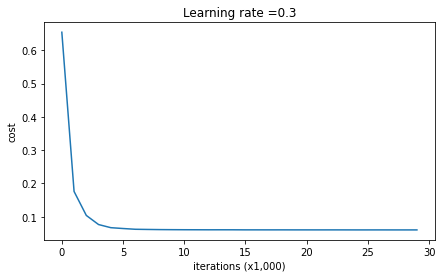

On the train set:
Accuracy: 0.9289099526066351
On the test set:
Accuracy: 0.95


In [ ]:
parameters = model(train_X, train_Y, keep_prob=0.86, learning_rate=0.3)

print("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

② Dropout 效果很好！测试精度再次提高（达到 95％）！模型并未过拟合训练集，并且在测试集上表现很好。法国足球队将永远感激你！

③ 运行以下代码以绘制决策边界，我们来看一下分类的结果吧。


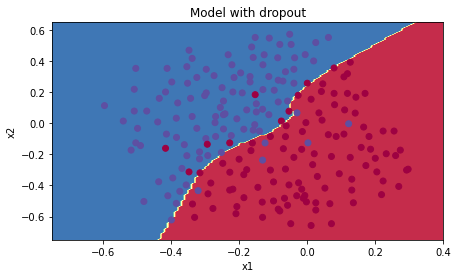

In [ ]:
plt.title("Model with dropout")
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(
    parameters, x.T), train_X, train_Y)

① λ 的值是可以使用开发集调整时的超参数。L2 正则化会使决策边界更加平滑。如果 λ 太大，也可能会“过度平滑”，从而导致模型高偏差。

② L2 正则化实际上在做什么？L2 正则化依赖于较小权重的模型比具有较大权重的模型更简单这样的假设，因此，通过削减成本函数中权重的平方值，可以将所有权重值逐渐改变到到较小的值。

③ 权值数值高的话会有更平滑的模型，其中输入变化时输出变化更慢，但是你需要花费更多的时间。L2 正则化对以下内容有影响：

1. 成本计算：正则化的计算需要添加到成本函数中
2. 反向传播功能：在权重矩阵方面，梯度计算时也要依据正则化来做出相应的计算
3. 重量变小（“重量衰减”)：权重被逐渐改变到较小的值。


note：

1. 使用 dropout 时的常见错误是在训练和测试中都使用。你只能在训练中使用 dropout（随机删除节点）。
2. 深度学习框架，例如 tensorflow, PaddlePaddle, keras 或者 caffe 附带 dropout 层的实现。不需强调-相信你很快就会学习到其中的一些框架。

关 dropout 你应该记住的事情：

1. dropout 是一种正则化技术。
2. 仅在训练期间使用 dropout，在测试期间不要使用。
3. 在正向和反向传播期间均应用 dropout。
4. 在训练期间，将每个 dropout 层除以 keep_prob，以保持激活的期望值相同。例如，如果 keep_prob 为 0.5，则平均而言，我们将关闭一半的节点，因此输出将按 0.5 缩放，因为只有剩余的一半对解决方案有所贡献。除以 0.5 等于乘以 2，因此输出现在具有相同的期望值。你可以检查此方法是否有效，即使 keep_prob 的值不是 0.5。


① 这是我们三个模型的结果：

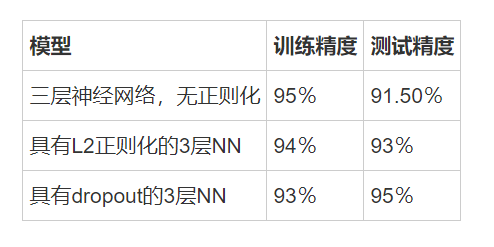


note：正则化会损害训练集的性能！ 这是因为它限制了网络过拟合训练集的能力。 但是，由于它最终可以提供更好的测试准确性，因此可以为你的系统提供帮助。

② 恭喜你完成此作业！同时也帮助了法国足球。


# 5. 总结


① 我们希望你从此次作业中记住的内容：

1. 正则化将帮助减少过拟合。
2. 正则化将使权重降低到较低的值。
3. L2 正则化和 Dropout 是两种非常有效的正则化技术。


# **_深度神经网络的梯度检验_**


# 0. 要解决的问题


① 假设你现在是一个全球移动支付团队中的一员，现在需要建立一个深度学习模型去判断用户账户在进行付款的时候是否是被黑客入侵的。

② 但是，在我们执行反向传播的计算过程中，反向传播函数的计算过程是比较复杂的。为了验证我们得到的反向传播函数是否正确，现在你需要编写一些代码来验证反向传播函数的正确性。


# 1. 导入库


In [ ]:
import numpy as np
from gc_utils import sigmoid, relu, dictionary_to_vector, vector_to_dictionary, gradients_to_vector
from testCase import *

# 2. 梯度检验原理


① 反向传播计算梯度$\frac{\partial J}{\partial \theta}$，其中$\theta$表示模型的参数。使用正向传播和损失函数来计算$J$。

② 由于正向传播相对容易实现，相信你有信心能做到这一点，确定 100％计算正确的损失$J$。为此，你可以使用$J$来验证代码$\frac{\partial J}{\partial \theta}$。

③ 让我们回顾一下导数（或者说梯度）的定义：$\frac{\partial J}{\partial \theta} = \lim_{\varepsilon \to 0} \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2 \varepsilon} \tag{3}$

④ 如果你还不熟悉"$\displaystyle \lim_{\varepsilon \to 0}$"表示法，其意思只是“当$\varepsilon$值趋向很小时”。

⑤ 我们知道以下内容：

1. $\frac{\partial J}{\partial \theta}$是你要确保计算正确的对象。
2. 你可以计算$J(\theta + \varepsilon)$和$J(\theta - \varepsilon)$（在$\theta$是实数的情况下），因为要保证$J$的实现是正确的。
3. 让我们使用方程式（1）和 $\varepsilon$ 的一个小值来说服 CEO 你计算$\frac{\partial J}{\partial \theta}$的代码是正确的！


# 2. 一维梯度检查


① 思考一维线性函数$J(\theta) = \theta x$，该模型仅包含一个实数值参数$\theta$，并以$x$作为输入。

② 你将实现代码以计算 $J(.)$ 及其派生 $\frac{\partial J}{\partial \theta}$，然后，你将使用梯度检验来确保$J$的导数计算正确。


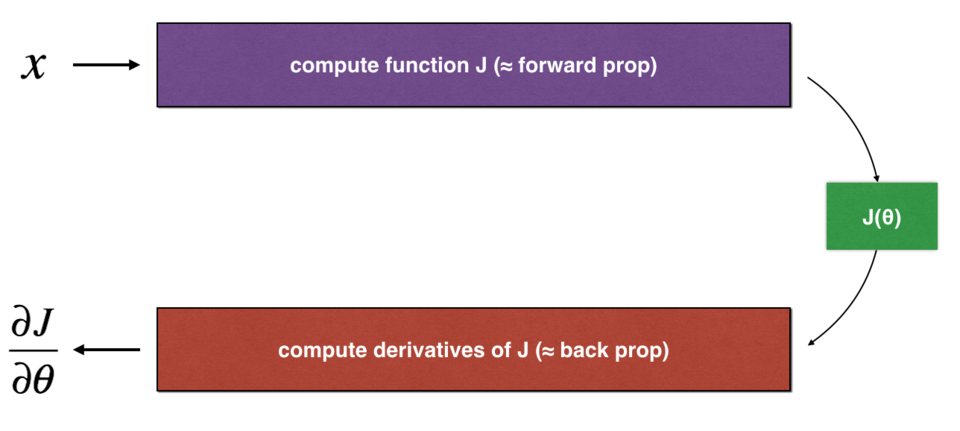

<center>图3：一维线性模型</center>


① 上图显示了关键的计算步骤：首先从$x$开始，再评估函数$J(x)$（正向传播），然后计算导数$\frac{\partial J}{\partial \theta}$（反向传播）。

② 练习：为此简单函数实现“正向传播”和“向后传播”。 即在两个单独的函数中，计算$J(.)$（正向传播）及其相对于$\theta$（反向传播）的导数。


In [ ]:
def forward_propagation(x, theta):
    """
    实现图中呈现的线性前向传播（计算J）（J（theta）= theta * x）

    参数：
    x  - 一个实值输入
    theta  - 参数，也是一个实数

    返回：
    J  - 函数J的值，用公式J（theta）= theta * x 计算
    """

    J = np.dot(theta, x)

    return J

In [ ]:
# 测试 forward_propagation
print("======我们来测试一下======")
x, theta = 2, 4
J = forward_propagation(x, theta)
print("J = " + str(J))

======我们来测试一下======
J = 8


练习：现在，执行图 1 的反向传播步骤（导数计算）。也就是说，计算$J(\theta) = \theta x$相对于$\theta$的导数。为避免进行演算，你应该得到$d\theta = \frac { \partial J }{ \partial \theta} = x$。

① 前向传播有了，我们来看一下反向传播：


In [ ]:
def backward_propagation(x, theta):
    """
    计算J相对于θ的导数。

    参数：
        x  - 一个实值输入
        theta  - 参数，也是一个实数

    返回：
        dtheta  - 相对于θ的成本梯度
    """
    dtheta = x

    return dtheta

In [ ]:
# 测试 backward_propagation
print("======我们来测试一下======")
x, theta = 2, 4
dtheta = backward_propagation(x, theta)
print("dtheta = " + str(dtheta))

======我们来测试一下======
dtheta = 2


① 为了展示 backward_propagation（）函数正确计算了梯度$\frac{\partial J}{\partial \theta}$，让我们实施梯度检验。

② 梯度检查的步骤如下：

- 首先使用上式（1）和$\varepsilon$的极小值计算“gradapprox”。以下是要遵循的步骤：

1. $\theta^{+} = \theta + \varepsilon$
2. $\theta^{-} = \theta - \varepsilon$
3. $J^{+} = J(\theta^{+})$
4. $gradapprox = \frac{J^{+} - J^{-}}{2  \varepsilon}$

- 然后使用反向传播计算梯度，并将结果存储在变量“grad”中
- 最后，使用以下公式计算“gradapprox”和“grad”之间的相对差：
  $difference = \frac {\mid\mid grad - gradapprox \mid\mid_2}{\mid\mid grad \mid\mid_2 + \mid\mid gradapprox \mid\mid_2} \tag{4}$

③ 你需要 3 个步骤来计算此公式：

1.  使用 np.linalg.norm（...）计算分子
2.  计算分母，调用 np.linalg.norm（...）两次
3.  相除

④ 当 difference 小于$10^{-7}$时，我们通常认为我们计算的结果是正确的。


In [ ]:
def gradient_check(x, theta, epsilon=1e-7):
    """

    实现图中的反向传播。

    参数：
        x  - 一个实值输入
        theta  - 参数，也是一个实数
        epsilon  - 使用公式（3）计算输入的微小偏移以计算近似梯度

    返回：
        近似梯度和后向传播梯度之间的差异
    """

    # 使用公式（3）的左侧计算gradapprox。
    thetaplus = theta + epsilon                               # Step 1
    thetaminus = theta - epsilon                              # Step 2
    J_plus = forward_propagation(x, thetaplus)                # Step 3
    J_minus = forward_propagation(x, thetaminus)              # Step 4
    gradapprox = (J_plus - J_minus) / (2 * epsilon)           # Step 5

    # 检查 gradapprox 是否足够接近 backward_propagation（）的输出
    grad = backward_propagation(x, theta)

    numerator = np.linalg.norm(
        grad - gradapprox)                      # Step 1'
    denominator = np.linalg.norm(
        grad) + np.linalg.norm(gradapprox)    # Step 2'
    difference = numerator / denominator                               # Step 3'

    if difference < 1e-7:
        print("梯度检查：梯度正常!")
    else:
        print("梯度检查：梯度超出阈值!")

    return difference

In [39]:
# 测试 gradient_check
print("======我们来测试一下======")
x, theta = 2, 4
difference = gradient_check(x, theta)
print("difference = " + str(difference))

======我们来测试一下======
梯度检查：梯度正常!
difference = 2.919335883291695e-10


① Nice！差异小于阈值$10^{-7}$。因此可以放心，你已经在 backward_propagation（）中正确计算了梯度。

② 现在，在更一般的情况下，你的损失函数$J$具有多个单个 1D 输入。当你训练神经网络时，$\theta$实际上由多个矩阵$W^{[l]}$组成，并加上偏差$b^{[l]}$！重要的是要知道如何对高维输入进行梯度检验。我们开始动手吧！


# 3. N 维梯度检验


① 高维参数是怎样计算的呢？我们看一下下图：


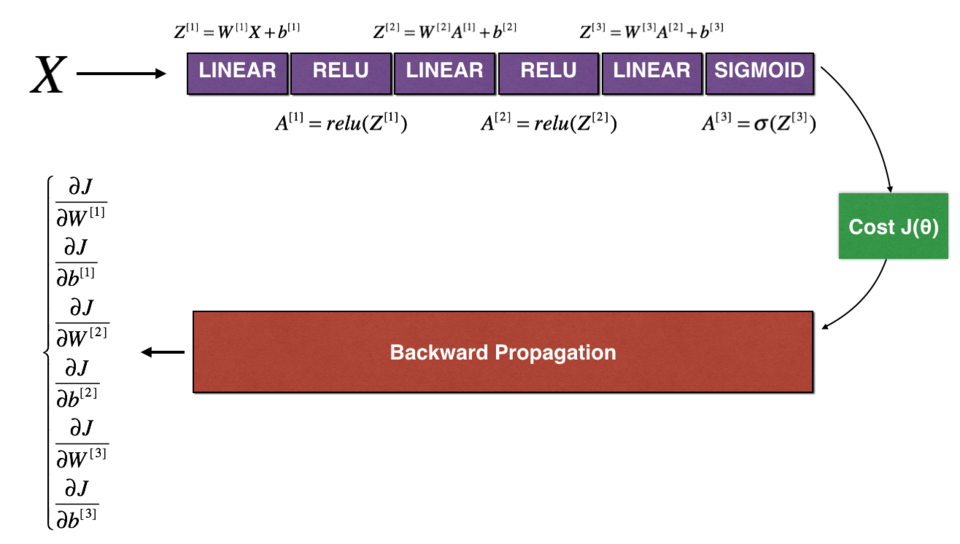

<center>图4：深层神经网络</center>
<center>图4：LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID</center>


② 让我们看一下正向传播和反向传播的实现。


In [ ]:
def forward_propagation_n(X, Y, parameters):
    """
    实现图中的前向传播（并计算成本）。

    参数：
        X - 训练集为m个例子
        Y -  m个示例的标签
        parameters - 包含参数“W1”，“b1”，“W2”，“b2”，“W3”，“b3”的python字典：
            W1  - 权重矩阵，维度为（5,4）
            b1  - 偏向量，维度为（5,1）
            W2  - 权重矩阵，维度为（3,5）
            b2  - 偏向量，维度为（3,1）
            W3  - 权重矩阵，维度为（1,3）
            b3  - 偏向量，维度为（1,1）

    返回：
        cost - 成本函数（logistic）
    """
    m = X.shape[1]
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    # 计算成本
    logprobs = np.multiply(-np.log(A3), Y) + \
        np.multiply(-np.log(1 - A3), 1 - Y)
    cost = (1 / m) * np.sum(logprobs)

    cache = (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3)

    return cost, cache

In [ ]:
def backward_propagation_n(X, Y, cache):
    """
    实现图中所示的反向传播。

    参数：
        X - 输入数据点（输入节点数量，1）
        Y - 标签
        cache - 来自forward_propagation_n（）的cache输出

    返回：
        gradients - 一个字典，其中包含与每个参数、激活和激活前变量相关的成本梯度。
    """

    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = 1./m * np.dot(dZ3, A2.T)
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = np.dot(W3.T, dZ3)
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1./m * np.dot(dZ2, A1.T) * 2
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1./m * np.dot(dZ1, X.T)
    db1 = 4./m * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,
                 "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
                 "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}

    return gradients

③ 你在欺诈检测测试集上获得了初步的实验结果，但是这并不是 100％确定的模型，毕竟没有东西是完美的！让我们实现梯度检验以验证你的梯度是否正确。


# 4. 梯度检验原理


① 与 1 和 2 中一样，你想将“gradapprox”与通过反向传播计算的梯度进行比较。公式仍然是：

$\frac{\partial J}{\partial \theta} = \lim_{\varepsilon \to 0} \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2 \varepsilon} \tag{5}$

② 但是，$\theta$不再是标量。 而是一个叫做“参数”的字典。 我们为你实现了一个函数"dictionary_to_vector()"。它将“参数”字典转换为称为“值”的向量，该向量是通过将所有参数(W1, b1, W2, b2, W3, b3)重塑为向量并将它们串联而获得的。

③ 反函数是“vector_to_dictionary”，它输出回“parameters”字典。


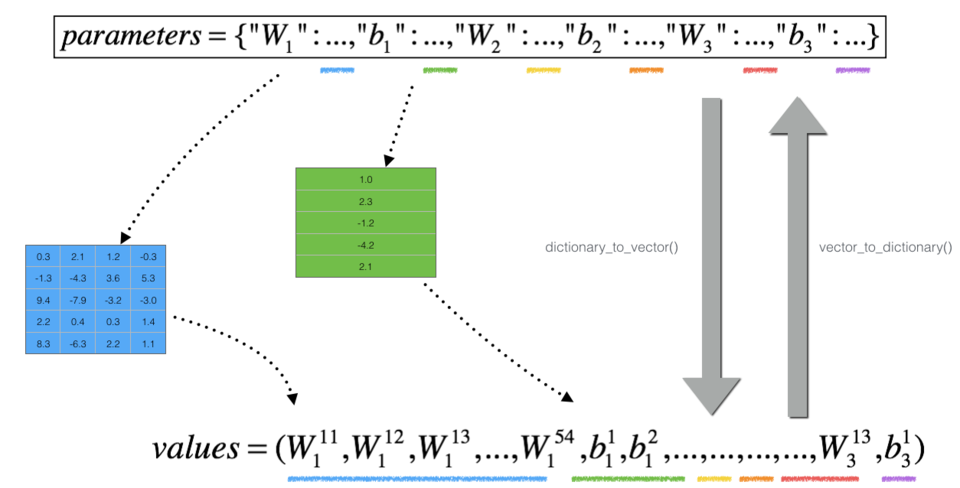

<center>图5：dictionary_to_vector（）和vector_to_dictionary（）</center>


① 你将在 gradient_check_n()中用到这些函数。

② 我们还使用 gradients_to_vector()将“gradients”字典转换为向量“grad”。

练习：实现 gradient_check_n()。

说明：这是伪代码，可帮助你实现梯度检验。

For each i in num_parameters:

- 计算 J_plus [i]：

1. 将$\theta^{+}$设为 `np.copy(parameters_values)`
2. 将$\theta^{+}_i$设为$\theta^{+}_i + \varepsilon$
3. 使用 forward_propagation_n(x, y, vector_to_dictionary($\theta^{+}$))计算
   $J^{+}_i$

- 计算 J_minus [i]：也是用$\theta^{-}$
- 计算$gradapprox[i] = \frac{J^{+}_i - J^{-}_i}{2 \varepsilon}$

因此，你将获得向量 gradapprox，其中 gradapprox[i]是相对于 parameter_values[i]的梯度的近似值。现在，你可以将此 gradapprox 向量与反向传播中的梯度向量进行比较。就像一维情况（步骤 1'，2'，3'）一样计算：$difference = \frac {\| grad - gradapprox \|_2}{\| grad \|_2 + \| gradapprox \|_2 } \tag{6}$


In [ ]:
def gradient_check_n(parameters, gradients, X, Y, epsilon=1e-7):
    """
    检查backward_propagation_n是否正确计算forward_propagation_n输出的成本梯度

    参数：
        parameters - 包含参数“W1”，“b1”，“W2”，“b2”，“W3”，“b3”的python字典：
        grad_output_propagation_n的输出包含与参数相关的成本梯度。
        x  - 输入数据点，维度为（输入节点数量，1）
        y  - 标签
        epsilon  - 计算输入的微小偏移以计算近似梯度

    返回：
        difference - 近似梯度和后向传播梯度之间的差异
    """
    # 初始化参数
    parameters_values, keys = dictionary_to_vector(parameters)  # keys用不到
    grad = gradients_to_vector(gradients)
    num_parameters = parameters_values.shape[0]
    J_plus = np.zeros((num_parameters, 1))
    J_minus = np.zeros((num_parameters, 1))
    gradapprox = np.zeros((num_parameters, 1))

    # 计算 gradapprox
    for i in range(num_parameters):
        # 计算 J_plus [i]。输入：“parameters_values，epsilon”。输出=“J_plus [i]”
        # Step 1
        thetaplus = np.copy(parameters_values)
        thetaplus[i][0] = thetaplus[i][0] + \
            epsilon                                             # Step 2
        J_plus[i], cache = forward_propagation_n(
            X, Y, vector_to_dictionary(thetaplus))  # Step 3 ，cache用不到

        # 计算 J_minus [i]。输入：“parameters_values，epsilon”。输出=“J_minus [i]”。
        # Step 1
        thetaminus = np.copy(parameters_values)
        thetaminus[i][0] = thetaminus[i][0] - \
            epsilon                                           # Step 2
        J_minus[i], cache = forward_propagation_n(
            X, Y, vector_to_dictionary(thetaminus))  # Step 3 ，cache用不到

        # 计算 gradapprox[i]
        gradapprox[i] = (J_plus[i] - J_minus[i]) / (2 * epsilon)

    # 通过计算差异比较 gradapprox 和后向传播梯度
    # Step 1'
    numerator = np.linalg.norm(grad - gradapprox)
    denominator = np.linalg.norm(
        grad) + np.linalg.norm(gradapprox)                   # Step 2'
    # Step 3'
    difference = numerator / denominator

#     if difference < 1e-7:
#         print("梯度检查：梯度正常!")
#     else:
#         print("梯度检查：梯度超出阈值!")

    if difference > 1e-7:
        print("\033[93m" + "There is a mistake in the backward propagation! difference = " +
              str(difference) + "\033[0m")
    else:
        print("\033[92m" + "Your backward propagation works perfectly fine! difference = " +
              str(difference) + "\033[0m")

    return difference

In [43]:
X, Y, parameters = gradient_check_n_test_case()

cost, cache = forward_propagation_n(X, Y, parameters)
gradients = backward_propagation_n(X, Y, cache)
difference = gradient_check_n(parameters, gradients, X, Y)

There is a mistake in the backward propagation! difference = 0.285093156780699


① 看起来 backward_propagation_n 代码似乎有错误！很好，你已经实现了梯度检验。

② 返回到 backward_propagation 并尝试查找/更正错误（提示：检查 dW2 和 db1）。

③ 如果你已解决问题，请重新运行梯度检验。请记住，如果修改代码，则需要重新执行定义 backward_propagation_n()的单元格。

④ 你可以进行梯度检验来证明你的导数计算的正确吗？即使作业的这一部分没有评分，我们也强烈建议你尝试查找错误并重新运行梯度检验，直到确信实现了正确的反向传播。

note：

1. 梯度检验很慢！用$\frac{\partial J}{\partial \theta} \approx  \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2 \varepsilon}$逼近梯度在计算上是很耗费资源的。因此，我们不会在训练期间的每次迭代中都进行梯度检验。只需检查几次梯度是否正确。
2. 至少如我们介绍的那样，梯度检验不适用于 dropout。通常，你将运行不带 dropout 的梯度检验算法以确保你的 backprop 是正确的，然后添加 dropout。
   Nice！现在你可以确信你用于欺诈检测的深度学习模型可以正常工作！甚至可以用它来说服你的 CEO。 :)


# 5. 总结


你在此笔记中应记住的内容：

- 梯度检验可验证反向传播的梯度与梯度的数值近似值之间的接近度（使用正向传播进行计算）。
- 梯度检验很慢，因此我们不会在每次训练中都运行它。通常，你仅需确保其代码正确即可运行它，然后将其关闭并将 backprop 用于实际的学习过程。
